In [1]:
import pandas as pd
import numpy as np
import nibabel as nb
import nitools as nt
import pyvista as pv
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import os
import globals as gl
from pcm_cortical import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from matplotlib.lines import Line2D
from scipy.stats import linregress, t, permutation_test
import pickle
import pingouin as pg
from util import lp_filter

from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib import colormaps as cm
from vis import make_yref

# Define the updated function and test it on the provided file
def load_border_vertices_xml(filepath):
    vertices = []
    inside_vertices_block = False
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if "<Vertices>" in line:
                inside_vertices_block = True
                line = line.replace("<Vertices>", "")
            if inside_vertices_block:
                if "</Vertices>" in line:
                    line = line.replace("</Vertices>", "")
                    inside_vertices_block = False
                if line:
                    numbers = [int(x) for x in line.split()]
                    vertices.extend(numbers)
    return np.array(vertices)

plt.style.use('default')
plt.style.use('dark_background')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


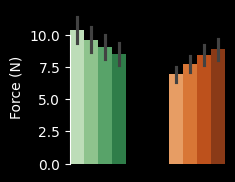

In [2]:
experiment = 'smp2'

snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]

dat = pd.DataFrame()
for sn in snS:
    dat_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}',f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    dat_tmp['sn'] = sn
    dat_tmp['stimFinger'] = dat_tmp['stimFinger'].map(gl.stimFinger_mapping)
    dat_tmp['cue'] = dat_tmp['cue'].map(gl.cue_mapping)
    dat_tmp = dat_tmp[dat_tmp['GoNogo'] == 'go']
    dat = pd.concat([dat, dat_tmp], ignore_index=True)

dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))

sns.barplot(dat[dat['stimFinger']=='index'], x='cue', y='index1', ax=axs[0], errorbar='se', width=1, palette=list(gl.colour_mapping.values())[5:9], order=list(gl.regressor_mapping)[0:4])
sns.barplot(dat[dat['stimFinger']=='ring'], x='cue', y='ring1', ax=axs[1], errorbar='se',
            width=1,  palette=list(gl.colour_mapping.values())[9:13], order=list(gl.regressor_mapping)[1:5])

for ax in axs:
    ax.set_xticks([])
    ax.spines[['bottom', 'right', 'top']].set_visible(False)
    ax.set_xlabel('')

axs[0].spines[['left']].set_bounds(0, 10)
axs[1].spines[['left']].set_visible(False)
axs[1].tick_params(width=0)
axs[0].set_ylabel('Force (N)')

plt.show()

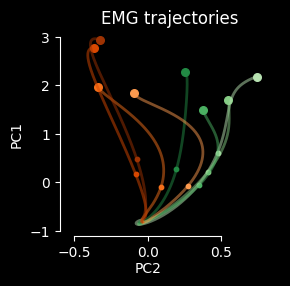

In [23]:
experiment = 'smp0'
snS = [100, 101, 102, 104, 105, 106, 107, 108, 109, 110]

wins = [(-.1, 0.0), (.025, .05), (.05, .1), (.1, .5)]
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
onset = 2148

pc = {
    '100-0,index': [],
    '75-25,index': [],
    '50-50,index': [],
    '25-75,index': [],
    '75-25,ring': [],
    '50-50,ring': [],
    '25-75,ring': [],
    '0-100,ring': [],
}

fs = 2148
onset = int(1 * fs)
start = onset - int(.02 * fs)
end = onset + int(.2 * fs)
via = onset + int(.1 * fs)

N = 10

for sn in snS:
    pc_tmp = np.load(os.path.join(gl.baseDir, experiment, 'emg', f'subj{sn}', 'pcs.npy'))
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')

    dat.stimFinger = dat.stimFinger.map(gl.stimFinger_mapping)
    dat.cue = dat.cue.map(gl.cue_mapping)

    for cue in dat.cue.unique():
        for stimFinger in dat.stimFinger.unique():
            if f'{cue},{stimFinger}' in pc.keys():
                pc[f'{cue},{stimFinger}'].append(pc_tmp[(dat.cue == cue) & (dat.stimFinger == stimFinger)])

fig, ax = plt.subplots(figsize=(3, 3))

for k, v in pc.items():
    pc[k] = np.array(v).mean(axis=1)
    pc_avg = pc[k].mean(axis=0)
    pc_avg_filt = lp_filter(pc_avg, 10, fs,)
    ax.plot(pc_avg_filt[1, start:end], pc_avg_filt[0, start:end], color=gl.colour_mapping[k], alpha=.5, lw=2)
    ax.scatter(pc_avg_filt[1, end], pc_avg_filt[0, end], color=gl.colour_mapping[k], s=30)
    ax.scatter(pc_avg_filt[1, via], pc_avg_filt[0, via], color=gl.colour_mapping[k], s=10)

ax.set_xlim([-.6, .9])
ax.set_ylim([-1.1, 3.1])

ax.spines[['top', 'right', ]].set_visible(False)
ax.spines[['bottom', ]].set_bounds(-.5, .5)
ax.spines[['left', ]].set_bounds(-1, 3)

ax.set_xlabel('PC2')
ax.xaxis.set_label_coords(0.4, -.13)
ax.set_ylabel('PC1')

ax.set_title('EMG trajectories')

fig.tight_layout()

plt.show()


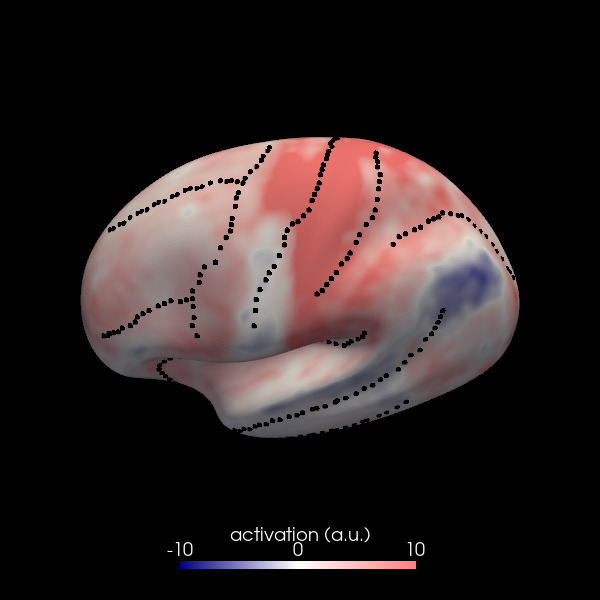

In [17]:
experiment = 'smp2'
glm = 12
dtype = 'con'
H = 'L'

# Define colors with non-uniform positions to steepen the extremities
colors = [
    (0.0, '#000080'),   # Navy
    (0.5, 'white'),    # Symmetric midpoint
    (1.0, '#FF7F7F')    # Saturated peach
]

# Create custom colormap with steeper outer transitions
cmap = LinearSegmentedColormap.from_list('steep_navy_peach', colors)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
column_names = cifti.header.get_axis(0).name
giftis = nt.split_cifti_to_giftis(cifti, type='func', column_names=column_names)

p = pv.Plotter(window_size=(600, 600))

# for h, H in enumerate(Hem):

surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
coords = surf.darrays[0].data
faces = surf.darrays[1].data.astype(np.uint32)  # pyvista requires uint32
data = nt.get_gifti_data_matrix(giftis[0])[:, 1]
faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
if H=='L':
    sulc = sulc[:len(data)]
else:
    sulc = sulc[len(data):]

# Now create the mesh
mesh = pv.PolyData(coords, faces)
mesh.point_data["overlay"] = data

mesh.point_data["sulc"] = sulc

border_verts = load_border_vertices_xml(f'/home/UWO/memanue5/Documents/GitHub/surfAnalysisPy/standard_mesh/fs_{H}/fs_LR.32k.{H}.border')
border = coords[border_verts]

p.add_mesh(mesh, scalars="sulc", cmap="Greys", clim=[-2, 2], lighting=True, show_scalar_bar=False)
p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-10, 10], lighting=True, show_scalar_bar=False)
p.add_scalar_bar(title="activation (a.u.)",
             n_labels=3,                 # Show fewer ticks
             vertical=False,            # Horizontal layout
             color='w',
             shadow=True,
             fmt="%.0f",
             position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
             position_y=0.05, # Lower position (closer to bottom of figure)
             width=0.4,       # Proportion of figure width
             height=0.04)
p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background("k")
p.view_vector((-1, 0, .8))        # start from a good view
 # dorsal view

p.show()

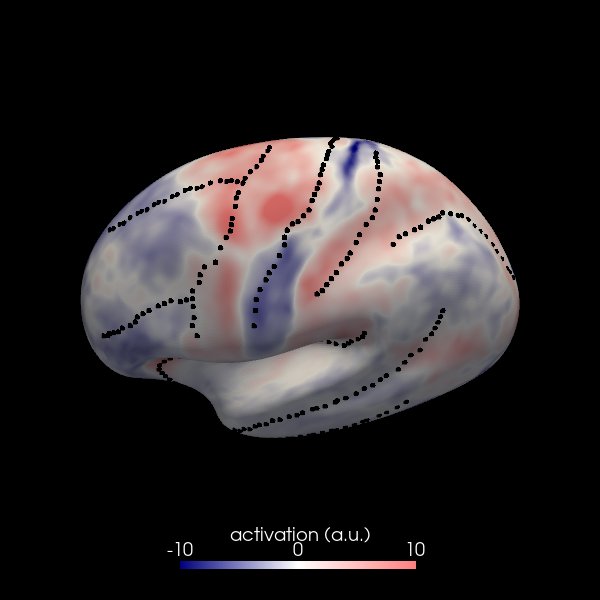

In [18]:
experiment = 'smp2'
glm = 12
dtype = 'con'
H = 'L'

# Define colors with non-uniform positions to steepen the extremities
colors = [
    (0.0, '#000080'),   # Navy
    (0.5, 'white'),    # Symmetric midpoint
    (1.0, '#FF7F7F')    # Saturated peach
]

# Create custom colormap with steeper outer transitions
cmap = LinearSegmentedColormap.from_list('steep_navy_peach', colors)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
column_names = cifti.header.get_axis(0).name
giftis = nt.split_cifti_to_giftis(cifti, type='func', column_names=column_names)

p = pv.Plotter(window_size=(600, 600))

# for h, H in enumerate(Hem):

surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
coords = surf.darrays[0].data
faces = surf.darrays[1].data.astype(np.uint32)  # pyvista requires uint32
data = nt.get_gifti_data_matrix(giftis[0])[:, 0]
faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
if H=='L':
    sulc = sulc[:len(data)]
else:
    sulc = sulc[len(data):]

# Now create the mesh
mesh = pv.PolyData(coords, faces)
mesh.point_data["overlay"] = data

mesh.point_data["sulc"] = sulc

border_verts = load_border_vertices_xml(f'/home/UWO/memanue5/Documents/GitHub/surfAnalysisPy/standard_mesh/fs_{H}/fs_LR.32k.{H}.border')
border = coords[border_verts]

p.add_mesh(mesh, scalars="sulc", cmap="Greys", clim=[-2, 2], lighting=True, show_scalar_bar=False)
p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-10, 10], lighting=True, show_scalar_bar=False)
p.add_scalar_bar(title="activation (a.u.)",
             n_labels=3,                 # Show fewer ticks
             vertical=False,            # Horizontal layout
             color='w',
             shadow=True,
             fmt="%.0f",
             position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
             position_y=0.05, # Lower position (closer to bottom of figure)
             width=0.4,       # Proportion of figure width
             height=0.04)
p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background("k")
p.view_vector((-1, 0, .8))        # start from a good view
 # dorsal view

p.show()

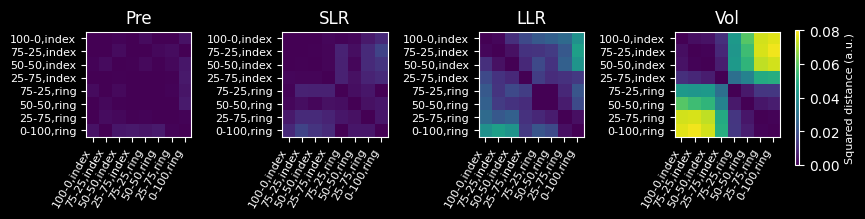

In [33]:
experiment = 'smp0'

vmin, vmax = -0., .08

epochs = ['Pre', 'SLR', 'LLR', 'Vol']

fig, axs = plt.subplots(1, 4, figsize=(8, 3))

for e, epoch in enumerate(epochs):
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy'))
    D = pcm.G_to_dist(G_obs.mean(axis=(0,)))

    ax = axs[e]

    cax = ax.imshow(D, vmin=vmin, vmax=vmax)
    ax.set_title(f'{epoch}')

    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)
    ax.set_xticks(ax.get_yticks())
    ax.set_xticklabels(ax.get_yticklabels(), fontsize=8, rotation=60, ha='right')

# Colorbar for imshow (top row)
bbox = axs[0].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('dissimilarity (a.u.)', fontsize=8)

fig.tight_layout()

plt.show()

Epoch: Pre, TtestResult(statistic=np.float64(2.3854053722966273), pvalue=np.float64(0.02043200835237465), df=np.int64(9))
Epoch: SLR, TtestResult(statistic=np.float64(1.6994250642526638), pvalue=np.float64(0.06172929005311001), df=np.int64(9))
Epoch: LLR, TtestResult(statistic=np.float64(2.7917368224329557), pvalue=np.float64(0.01049708635388353), df=np.int64(9))
Epoch: Vol, TtestResult(statistic=np.float64(5.143034547931599), pvalue=np.float64(0.00030440377390180724), df=np.int64(9))


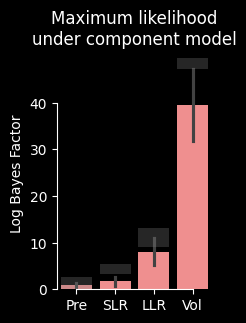

In [17]:
# Settings
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
experiment = 'smp0'

# Initialize container
LL = {
    'epoch': [],
    'noise_upper': [],
    'noise_lower': [],
    'baseline': [],
    'likelihood': [],
}

# Load and organize data
for epoch in epochs:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.{epoch}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.{epoch}.p'))

    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['epoch'].extend([epoch] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

# Convert to DataFrame
LL = pd.DataFrame(LL)

# Baseline subtraction
baseline = LL['baseline'].values
LL[['noise_upper', 'noise_lower', 'likelihood']] = LL[['noise_upper', 'noise_lower', 'likelihood']] - baseline.reshape(-1, 1)

# Plotting
fig, ax = plt.subplots(figsize=(2, 3))
width = 0.8

sns.barplot(data=LL, x='epoch', y='likelihood', ax=ax, width=width, errorbar='se', color='#FF7F7F')

# Add shaded noise ceiling
for e, epoch in enumerate(epochs):
    print(f"Epoch: {epoch}, {ttest_1samp(LL[LL['epoch'] == epoch]['likelihood'], 0, alternative='greater')}")
    noise_upper = LL[LL['epoch'] == epoch]['noise_upper'].mean()
    noise_lower = LL[LL['epoch'] == epoch]['noise_lower'].mean()
    noiserect = Rectangle(
        (e - width / 2, noise_lower),
        width,
        noise_upper - noise_lower,
        linewidth=0,
        facecolor=[0.5, 0.5, 0.5, 0.2],
        zorder=1e6,
        alpha=0.3
    )
    ax.add_patch(noiserect)

# Aesthetics
# ax.set_yscale('symlog')
ax.spines['left'].set_bounds(0, 40)
ax.set_ylabel('Log Bayes Factor')
ax.set_xlabel('')
ax.set_title('Maximum likelihood\nunder component model', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, len(epochs) - 1)

plt.show()

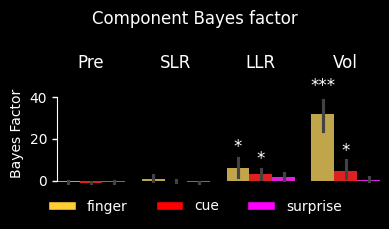

In [20]:
experiment = 'smp0'

components = ['finger', 'cue', 'surprise']

epochs = ['Pre', 'SLR', 'LLR', 'Vol']

M = make_execution_models()
M, _ = find_model(M, 'component')
G = M.Gc
MF = pcm.model.ModelFamily(G, comp_names=components, basecomponents=np.eye(8)[None,:,:])

fig, axs = plt.subplots(1, len(epochs), figsize=(4, 2), sharey=True, constrained_layout=True)

for r, epoch in enumerate(epochs):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.emg.{epoch}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf',palette=['#D4AF37', 'red', 'magenta'], width=1)

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0, alternative='greater')

        mean = vals.mean()
        sem = vals.std(ddof=1) / (n**0.5)
        ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
        bar_height = mean + ci

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].set_title(epoch)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(components, rotation=60, ha='right')
    axs[r].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
    axs[r].set_ylim([-5, 50])
    axs[r].spines[['bottom',]].set_bounds(0, 5)
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    axs[r].tick_params(width=0)

    if r == 0:
        axs[r].spines[['left', ]].set_visible(True)
        axs[r].spines[['left', ]].set_bounds(0, 40)
        axs[r].tick_params(width=1)

# Define legend handles
legend_handles = [
    Patch(facecolor='#FFCC33', edgecolor='black', label='finger'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=3,
           fontsize=10)

fig.suptitle('Component Bayes factor')

fig.tight_layout()

plt.show()

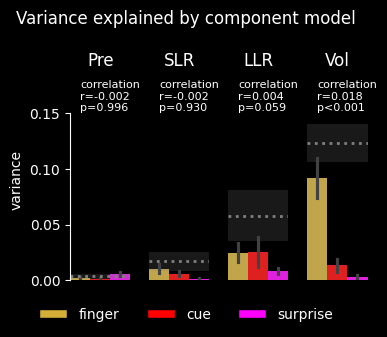

In [21]:
experiment = 'smp0'

epochs = ['Pre', 'SLR', 'LLR', 'Vol']

components = np.array(['finger', 'cue', 'surprise'])

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.emg.pkl'), 'component')
n_param_c = Mc.n_param

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.emg.pkl'), 'feature')
n_param_f = Mf.n_param

fig, axs = plt.subplots(1, len(epochs), figsize=(4, 3), sharey=True, )

inset_axs = []

for e, epoch in enumerate(epochs):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.p'), "rb")
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])

    ax = axs[e]
    params = pickle.load(f)

    # variance explained
    params_c = params[idxc]
    theta_c = params_c[:n_param_c]
    var_expl = np.exp(theta_c)

    # main axes
    sns.barplot(data=var_expl.T, ax=ax, palette=['#D4AF37', 'red', 'magenta'], errorbar='se', width=1)
    ax.set_title(epoch, pad=10)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(components, rotation=60, ha='right')
    ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
    ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
    if e == 0:
        ax.spines[['top', 'right','bottom',]].set_visible(False)
    else:
        ax.spines[['top', 'right','bottom','left']].set_visible(False)
        ax.tick_params(width=0)
    ax.spines[['left', ]].set_bounds(0, .15)
    ax.set_ylim((0, .18))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.set_ylabel('variance')
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    # correlation
    params_f = params[idxf]
    theta_f = params_f[:n_param_f]
    cov = theta_f[1] * theta_f[2]
    var1 = var_expl[0]
    var2 = var_expl[1]
    r = cov #/ np.sqrt(var1 * var2 + 1e-3)

    _, p_val_1samp = ttest_1samp(r, 0, alternative='greater')
    if p_val_1samp < 0.001:
        ax.text(0, .15,f'correlation\nr={r.mean():.3f}\np<0.001', fontsize=8, ha='left', va='bottom')
    else:
        ax.text(0, .15,f'correlation\nr={r.mean():.3f}\np={p_val_1samp:.3f}', fontsize=8, ha='left', va='bottom')


# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    # Patch(facecolor='cyan', edgecolor='black', label='correlation'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=4,
           fontsize=10)

fig.suptitle('Variance explained by component model')

fig.tight_layout()

plt.show()

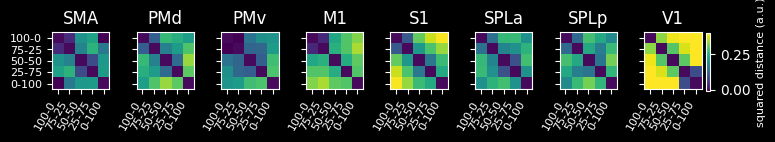

In [34]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

vmin, vmax = -.01, .4

fig, axs = plt.subplots(1, len(rois), figsize=(7, 3),sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs)
    D_obs = np.sign(D_obs) * np.sqrt(np.abs(D_obs))

    # Top row: imshow
    im_ax = axs[r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(5))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    # if r==0:
    im_ax.set_yticks(np.arange(5))
    im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)

bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('dissimilarity (a.u.)', fontsize=8)

plt.show()

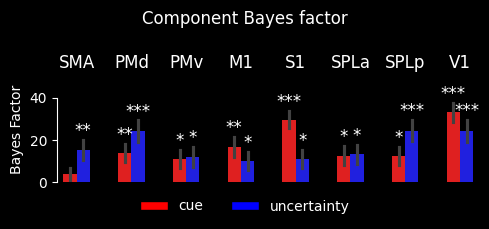

In [23]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

M = make_planning_models()
M, _ = find_model(M, 'component')
G = M.Gc
MF = pcm.model.ModelFamily(G, comp_names=['cue', 'uncertainty'], basecomponents=None)

fig, axs = plt.subplots(1, len(rois), figsize=(5, 2), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf', palette=['red', 'blue'],errorbar='se',width=1)

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0)

        mean = vals.mean()
        sem = vals.std(ddof=1) / (n**0.5)
        bar_height = mean + sem

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].spines[['left',]].set_bounds([0, 40])
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    if r == 0:
        axs[r].spines[['top', 'right','bottom',]].set_visible(False)
    else:
        axs[r].spines[['top', 'right','bottom','left']].set_visible(False)
        axs[r].tick_params(width=0)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')
    axs[r].set_title(roi)

for r in range(len(rois)):
    # axs[r].set_yscale('symlog')
    axs[r].set_ylim([0, 50])
    axs[r].set_xlim([-1, 2])

fig.suptitle('Component Bayes factor')


# Define legend handles
legend_handles = [
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=2,
           fontsize=10)

fig.tight_layout()
plt.show()

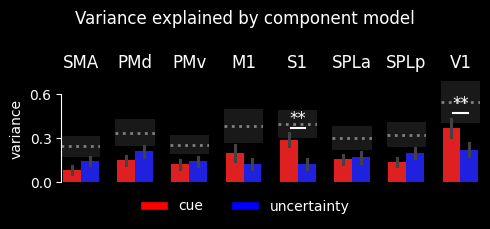

In [24]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['cue', 'uncertainty'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(5, 2),sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])
    tr_mean = np.sqrt(tr.mean())
    tr_err = np.sqrt(tr.std()) / np.sqrt(len(tr))

    # Bottom row: bar plot
    ax = axs[r]
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)

    df = pd.DataFrame(theta_sqrt.T, columns=features)

    sns.barplot(data=df, ax=ax, palette=['red', 'blue'], errorbar='se', width=1)
    ax.set_xticks([])
    ax.axhline(tr_mean, color='grey', lw=2, ls=':')
    ax.axhspan(tr_mean - tr_err,
                   tr_mean + tr_err, color='grey', alpha=.2, lw=0)
    ax.set_title(roi)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    # ax.set_xlim((-1, 2))
    ax.set_ylabel('variance')
    ax.set_yticks((0, .3, .6))
    ax.spines[['left',]].set_bounds(0, .6)
    if r > 0:
        ax.spines[['top', 'right','bottom','left']].set_visible(False)
        ax.tick_params(width=0)

    a = df['cue']
    b = df['uncertainty']

    _, p_val_paired = ttest_rel(a, b)

    # Significance stars
    if p_val_paired < 0.001:
        stars = '***'
    elif p_val_paired < 0.01:
        stars = '**'
    elif p_val_paired < 0.05:
        stars = '*'
    else:
        stars = None

    if stars:
        # Estimate max height for the bar
        y_max = np.max((a.mean() + a.std() / np.sqrt(len(a)),(b.mean() + b.std() / np.sqrt(len(b)))))

        # Compute x positions of the bars for the two models
        center = .5
        x1 = center - .4   # component
        x2 = center + .4   # feature

        # Draw bar and stars
        ax.plot([x1, x2], [y_max + .1 * y_max, y_max+ .1 * y_max], lw=1.5, c='w')
        ax.text(.5, y_max + .1 * y_max, stars, ha='center', va='bottom', fontsize=12)

fig.suptitle('Variance explained by component model')

# Define legend handles
legend_handles = [
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=2,
           fontsize=10)

fig.tight_layout()
plt.show()

ROI: SMA, TtestResult(statistic=np.float64(3.240273588483073), pvalue=np.float64(0.0032239106465261082), df=np.int64(13))
ROI: PMd, TtestResult(statistic=np.float64(2.4039533528025934), pvalue=np.float64(0.015924210890904487), df=np.int64(13))
ROI: PMv, TtestResult(statistic=np.float64(2.57868582929597), pvalue=np.float64(0.011456804556234788), df=np.int64(13))
ROI: M1, TtestResult(statistic=np.float64(2.090422465624917), pvalue=np.float64(0.028395344311236668), df=np.int64(13))
ROI: S1, TtestResult(statistic=np.float64(2.899377544260103), pvalue=np.float64(0.006211375465103722), df=np.int64(13))
ROI: SPLa, TtestResult(statistic=np.float64(1.847949784015954), pvalue=np.float64(0.04374131724691666), df=np.int64(13))
ROI: SPLp, TtestResult(statistic=np.float64(3.0484942502044743), pvalue=np.float64(0.004663481010110837), df=np.int64(13))
ROI: V1, TtestResult(statistic=np.float64(2.963735848445156), pvalue=np.float64(0.005489104556568168), df=np.int64(13))


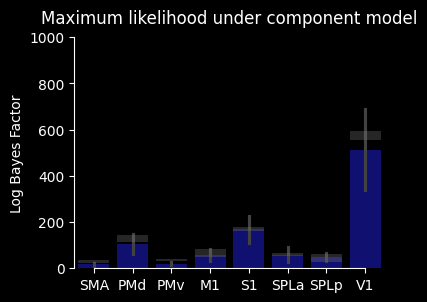

In [42]:
# Settings
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

# Initialize container
LL = {
    'roi': [],
    'noise_upper': [],
    'noise_lower': [],
    'baseline': [],
    'likelihood': [],
}

# Load and organize data
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{H}.{roi}.p'))

    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

# Convert to DataFrame
LL = pd.DataFrame(LL)

# Baseline subtraction
baseline = LL['baseline'].values
LL[['noise_upper', 'noise_lower', 'likelihood']] = LL[['noise_upper', 'noise_lower', 'likelihood']] - baseline.reshape(-1, 1)

# Plotting
fig, ax = plt.subplots(figsize=(4, 3))
width = 0.8

sns.barplot(data=LL, x='roi', y='likelihood', ax=ax, width=width, errorbar='se', color='#000080')

# Add shaded noise ceiling
for r, roi in enumerate(rois):
    print(f"ROI: {roi}, {ttest_1samp(LL[LL['roi'] == roi]['likelihood'], 0, alternative='greater')}")
    noise_upper = LL[LL['roi'] == roi]['noise_upper'].mean()
    noise_lower = LL[LL['roi'] == roi]['noise_lower'].mean()
    noiserect = Rectangle(
        (r - width / 2, noise_lower),
        width,
        noise_upper - noise_lower,
        linewidth=0,
        facecolor=[0.5, 0.5, 0.5, 0.2],
        zorder=1e6,
        alpha=0.3
    )
    ax.add_patch(noiserect)

# Aesthetics
# ax.set_yscale('symlog')
ax.set_ylim(0, 1000)
ax.set_ylabel('Log Bayes Factor')
ax.set_xlabel('')
ax.set_title('Maximum likelihood under component model', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, len(rois) - 1)

plt.show()

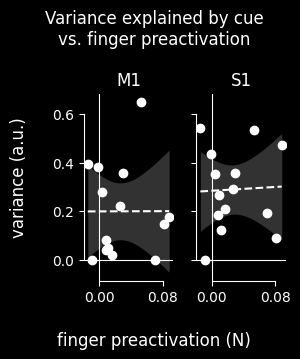

In [41]:
rois = ['M1', 'S1', ]
Hem = 'L'
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
experiment = 'smp2'
glm = 12

features = np.array(['cue', 'uncertainty'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

df = pd.DataFrame()
diff1, diff2, diff3 = np.zeros(len(snS)), np.zeros(len(snS)), np.zeros(len(snS))
for s, sn in enumerate(snS):
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df, df_tmp])
    diff1[s] = (df[df['cue'] == 39]['index0'].mean() - df[df['cue'] == 93]['index0'].mean() +
                df[df['cue'] == 93]['ring0'].mean() - df[df['cue'] == 39]['ring0'].mean()) / 2
    diff3[s] = (df[df['stimFinger'] == 91999]['index1'].mean() - df[df['stimFinger'] == 99919]['index1'].mean() +
                df[df['stimFinger'] == 99919]['ring1'].mean() - df[df['stimFinger'] == 91999]['ring1'].mean()) / 2
    diff2[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(3, 3.5))

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)

    # Regression for diff2
    x = diff2
    y = theta_sqrt[0]
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = slope * x_fit + intercept

    # Compute confidence intervals
    n = len(x)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    dof = n - 2
    t_val = t.ppf(0.975, dof)

    se_line = np.sqrt(
        np.sum(residuals**2) / dof * (1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    )
    ci = t_val * se_line

    axs[r].plot(x_fit, y_fit, color='w', linestyle='--', label='Fit')
    axs[r].fill_between(x_fit, y_fit - ci, y_fit + ci, color='w', alpha=.2, label='95% CI', lw=0)
    axs[r].scatter(x, y, color='w')

    axs[r].axvline(0, lw=.8, color='w')
    axs[r].axhline(0, lw=.8, color='w')

    axs[r].set_title(roi)

    # Remove spines from 'left', 'top', and 'right'
    axs[r].spines['left'].set_bounds(0, .6)
    axs[r].spines['bottom'].set_bounds(0.0, .08)
    axs[r].spines['top'].set_visible(False)
    axs[r].spines['right'].set_visible(False)

    # Set ticks for x-axis and y-axis
    axs[r].set_xticks(np.linspace(0, .08, 2))

fig.supxlabel('finger preactivation (N)')
fig.supylabel('variance (a.u.)')

fig.suptitle('Variance explained by cue\nvs. finger preactivation')

fig.tight_layout()


ROI: SMA, TtestResult(statistic=np.float64(2.9827139287988964), pvalue=np.float64(0.0052924665806444015), df=np.int64(13))
ROI: PMd, TtestResult(statistic=np.float64(3.3078672731453946), pvalue=np.float64(0.0028306897925133782), df=np.int64(13))
ROI: PMv, TtestResult(statistic=np.float64(5.0673430006301), pvalue=np.float64(0.00010788275840750906), df=np.int64(13))
ROI: M1, TtestResult(statistic=np.float64(3.3418881934065188), pvalue=np.float64(0.0026513900657694463), df=np.int64(13))
ROI: S1, TtestResult(statistic=np.float64(3.4752874777776244), pvalue=np.float64(0.0020520204639173046), df=np.int64(13))
ROI: SPLa, TtestResult(statistic=np.float64(5.1627644015976895), pvalue=np.float64(9.12794570477764e-05), df=np.int64(13))
ROI: SPLp, TtestResult(statistic=np.float64(2.28406610310727), pvalue=np.float64(0.01990897495241462), df=np.int64(13))
ROI: V1, TtestResult(statistic=np.float64(0.4852207472378897), pvalue=np.float64(0.31779716752312837), df=np.int64(13))


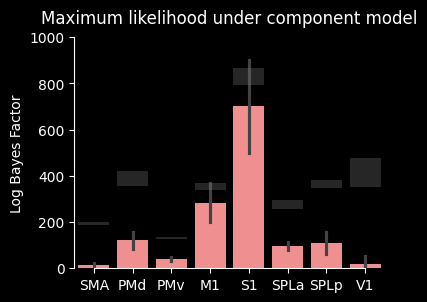

In [43]:
# Settings
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

# Initialize container
LL = {
    'roi': [],
    'noise_upper': [],
    'noise_lower': [],
    'baseline': [],
    'likelihood': [],
}

# Load and organize data
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{H}.{roi}.p'))

    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

# Convert to DataFrame
LL = pd.DataFrame(LL)

# Baseline subtraction
baseline = LL['baseline'].values
LL[['noise_upper', 'noise_lower', 'likelihood']] = LL[['noise_upper', 'noise_lower', 'likelihood']] - baseline.reshape(-1, 1)

# Plotting
fig, ax = plt.subplots(figsize=(4, 3))
width = 0.8

sns.barplot(data=LL, x='roi', y='likelihood', ax=ax, width=width, errorbar='se', color='#FF7F7F')

# Add shaded noise ceiling
for r, roi in enumerate(rois):
    print(f"ROI: {roi}, {ttest_1samp(LL[LL['roi'] == roi]['likelihood'], 0, alternative='greater')}")
    noise_upper = LL[LL['roi'] == roi]['noise_upper'].mean()
    noise_lower = LL[LL['roi'] == roi]['noise_lower'].mean()
    noiserect = Rectangle(
        (r - width / 2, noise_lower),
        width,
        noise_upper - noise_lower,
        linewidth=0,
        facecolor=[0.5, 0.5, 0.5, 0.2],
        zorder=1e6,
        alpha=0.3
    )
    ax.add_patch(noiserect)

# Aesthetics
# ax.set_yscale('symlog')
ax.set_ylim(0, 1000)
ax.set_ylabel('Log Bayes Factor')
ax.set_xlabel('')
ax.set_title('Maximum likelihood under component model', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_bounds(0, len(rois) - 1)

plt.show()

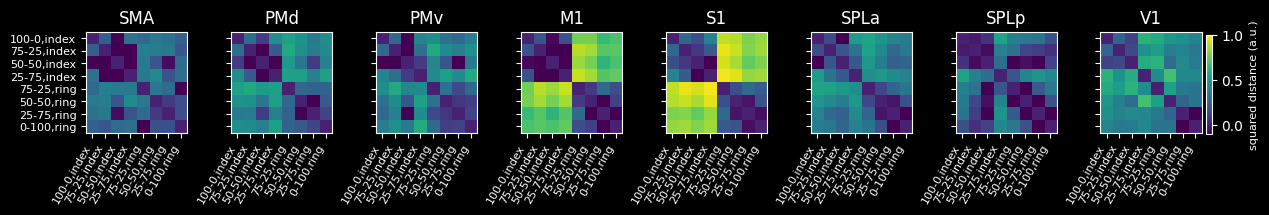

In [25]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

vmin, vmax = -.1, 1

fig, axs = plt.subplots(1, len(rois), figsize=(12, 4), sharey=True, sharex=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    G_obs_avg = G_obs.mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs_avg)
    D_obs = np.sign(D_obs) * np.sqrt(np.abs(D_obs))

    # Top row: imshow
    im_ax = axs[r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax, cmap='viridis')
    im_ax.set_xticks(np.arange(8))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    im_ax.set_yticks(np.arange(8))
    im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)

bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('squared distance (a.u.)', fontsize=8)


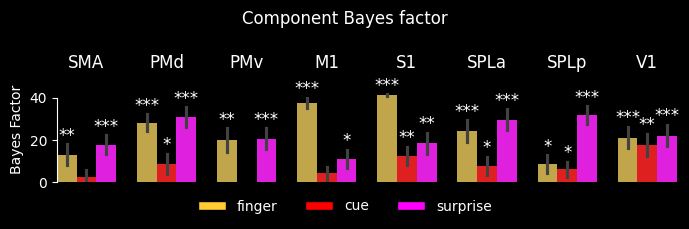

In [26]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

components = ['finger', 'cue', 'surprise']

M = make_execution_models()
M, _ = find_model(M, 'feature')
MF = pcm.model.ModelFamily(M, comp_names=components,)

fig, axs = plt.subplots(1, len(rois), figsize=(7, 2),  constrained_layout=True, sharey=True)

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf',palette=['#D4AF37', 'red', 'magenta'], errorbar='se', width=1)

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0, alternative='greater')

        mean = vals.mean()
        sem = vals.std() / np.sqrt(len(vals))
        bar_height = mean + sem

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].set_title(roi)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(components, rotation=60, ha='right')
    axs[r].spines[['top', 'right', 'bottom']].set_visible(False)
    if r>0:
        axs[r].spines[['left']].set_visible(False)
        axs[r].tick_params(width=0)
    axs[r].spines[['left', ]].set_bounds(0, 40)
    axs[r].set_ylim([0, 50])
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Define legend handles
legend_handles = [
    Patch(facecolor='#FFCC33', edgecolor='black', label='finger'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=6,
           fontsize=10)

fig.suptitle('Component Bayes factor')

fig.tight_layout()

plt.show()

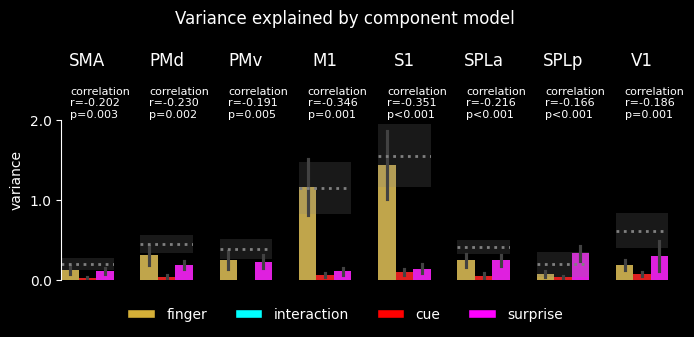

In [27]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

components = np.array(['finger', 'cue', 'surprise'])

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'component')
n_param_c = Mc.n_param

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'feature')
n_param_f = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(7, 3), sharey=True, constrained_layout=True)

inset_axs = []

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])

    ax = axs[r]
    params = pickle.load(f)

    # variance explained
    params_c = params[idxc]
    theta_c = params_c[:n_param_c]
    var_expl = np.exp(theta_c)

    # interaction
    params_f = params[idxf]
    theta_f = params_f[:n_param_f]
    interaction = theta_f[1, :] * theta_f[2, :]

    # main axes
    sns.barplot(data=var_expl.T, ax=ax, palette=['#D4AF37', 'red', 'magenta'], errorbar='se', width=1)
    ax.set_title(roi, pad=10)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(components, rotation=60, ha='right')
    # ax.hlines(0, 0, 3, color='w', lw=0.8)
    ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
    ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    if r>0:
        ax.spines[['left']].set_visible(False)
        ax.tick_params(width=0)
    ax.spines[['left', ]].set_bounds(0, 2)
    ax.set_yticks([-.5, 0, 1, 2])
    ax.set_ylim((0, 2.5))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.set_ylabel('variance')
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    # correlation
    params_f = params[idxf]
    theta_f = params_f[:n_param_f]
    cov = theta_f[1] * theta_f[2]
    var1 = theta_f[0] ** 2
    var2 = theta_f[2] ** 2
    epsilon = 1e-1
    r = cov #/ np.sqrt((var1 + epsilon) * (var2 + epsilon))

    _, p_val_1samp = ttest_1samp(r, 0, alternative='less')
    if p_val_1samp < 0.001:
        ax.text(0, 2,f'correlation\nr={r.mean():.3f}\np<0.001', fontsize=8, ha='left', va='bottom')
    else:
        ax.text(0, 2,f'correlation\nr={r.mean():.3f}\np={p_val_1samp:.3f}', fontsize=8, ha='left', va='bottom')

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=6,
           fontsize=10)

fig.suptitle('Variance explained by component model')
fig.tight_layout()

plt.show()

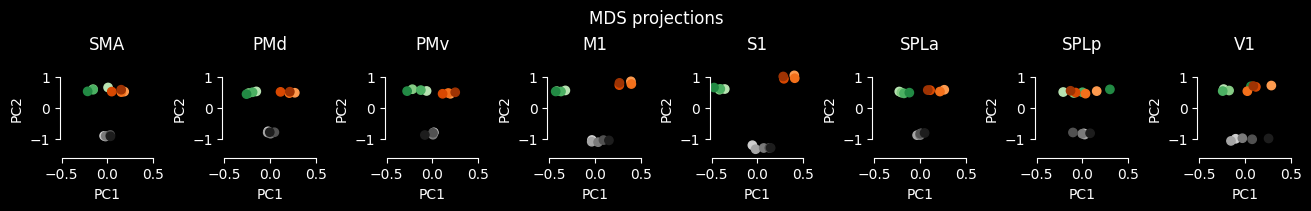

In [28]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

fig, axs = plt.subplots(1, len(rois), figsize=(13, 2), constrained_layout=True)

corrx = [-1, -1, -1, -1, -1, -1, -1, -1]
corry = [1, 1, -1,-1, -1, -1, -1, 1]

for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan-exec.glm{glm}.{Hem}.{roi}.npy')).mean(axis=0)
    mds, _ = pcm.classical_mds(G)

    axs[r].scatter(mds[:, 1] * corry[r], mds[:, 0] * corrx[r], c=list(gl.colour_mapping.values()))
    axs[r].set_title(roi)
    axs[r].set_ylim(-1.6, 1.6)
    axs[r].set_xlim(-.52, .52)
    axs[r].set_ylabel('PC2')
    axs[r].set_xlabel('PC1')
    axs[r].spines[['top', 'right']].set_visible(False)
    # axs[r].spines[['bottom', 'left']].set_linewidth(2)
    axs[r].spines[['bottom',]].set_bounds(-.5, .5)
    axs[r].spines[['left',]].set_bounds(-1, 1)
    # axs[r].tick_params(width=2)

fig.suptitle(f'MDS projections')

plt.show()

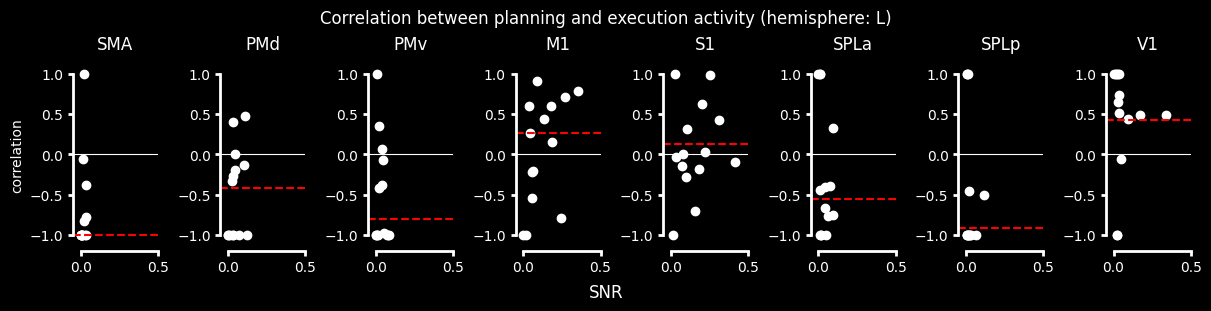

In [14]:
experiment = 'smp2'
glm = 12
H = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
N = 14

Mflex = pcm.CorrelationModel("flex", num_items=1, corr=None, cond_effect=False)

fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(12, 3), constrained_layout=True)

for r, roi in enumerate(rois):

    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.glm{glm}.{H}.{roi}.pkl'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.pkl'), 'rb')
    theta = pickle.load(f)

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.pkl'), 'rb')
    theta_g = pickle.load(f)

    sigma2_1 = np.exp(theta[0][0])
    sigma2_2 = np.exp(theta[0][1])
    r_indiv = Mflex.get_correlation(theta[0])
    sigma2_e = np.exp(theta[0][3])
    SNR = np.sqrt(sigma2_1*sigma2_2)/sigma2_e
    axs[r].scatter(SNR, r_indiv, color='w')

    theta_g,_= pcm.group_to_individ_param(theta_g[0],Mflex,N)
    r_group = Mflex.get_correlation(theta_g)
    axs[r].axhline(r_group[0], color='r', linestyle='--')
    axs[r].axhline(0, color='w', linestyle='-', lw=.8)
    axs[r].set_title(roi)

    axs[r].set_ylim(-1.2, 1.2)
    axs[r].set_xlim(-.05, .5)

    axs[r].spines[['top', 'right',]].set_visible(False)
    axs[r].spines[['bottom']].set_bounds(0, .5)
    axs[r].spines[['bottom', 'left']].set_linewidth(2)
    axs[r].tick_params(width=2)
    axs[r].spines[['left']].set_bounds(-1, 1)
    # axs[r].tick_params(axis='y', width=0)

    if r==0:
        axs[r].spines[['left']].set_visible(True)

        axs[r].spines[['left']].set_linewidth(2)
        axs[r].tick_params(axis='y', width=2)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between planning and execution activity')

plt.show()
